In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from scipy import stats
import os

### Loading the data

In [2]:
df = pd.read_csv('../data/sudan.csv')
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86


## **Data Loading & Date Parsing**

### Add a Country column with the Ethiopia value

In [3]:
df_clean = df.copy()

In [5]:
df_clean["Country"] = "Sudan"
df_clean.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan


### Convert the YEAR and DOY columns into a proper datetime column

In [6]:
df_clean["Date"] = pd.to_datetime(df_clean["YEAR"] * 1000 + df_clean["DOY"], format="%Y%j")
df_clean.drop(columns=["DOY"], inplace=True)
df_clean.sample(5)


,YEAR,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date
287,2015,35.44,42.41,29.26,13.15,0.00,19.70,1.58,2.74,96.09,7.02,Sudan,2015-10-15
1991,2020,35.21,42.43,28.57,13.86,0.00,38.01,5.05,7.35,96.09,13.11,Sudan,2020-06-14
1170,2018,26.80,37.73,16.81,20.92,0.00,10.72,3.26,4.92,96.24,2.08,Sudan,2018-03-16
3975,2025,27.79,35.81,20.38,15.43,0.00,32.84,3.92,5.58,96.45,7.58,Sudan,2025-11-19
3905,2025,28.21,35.74,24.07,11.67,0.15,61.69,2.92,6.59,96.43,14.74,Sudan,2025-09-10


### Extract Month as a separate colum

In [7]:
df_clean["Month"] = df_clean["Date"].dt.month
df_clean.sample(5)

,YEAR,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
1992,2020,34.29,39.75,28.92,10.83,1.03,39.72,4.03,5.48,96.21,13.41,Sudan,2020-06-15,6
912,2017,34.78,41.55,28.53,13.02,0.00,33.74,5.87,8.61,95.92,11.38,Sudan,2017-07-01,7
2512,2021,26.96,36.62,18.03,18.59,0.00,28.49,1.86,3.12,96.31,6.07,Sudan,2021-11-17,11
3886,2025,30.08,35.48,24.67,10.81,0.11,56.91,4.15,5.07,96.02,15.18,Sudan,2025-08-22,8
1121,2018,19.63,27.46,12.54,14.92,0.00,30.31,4.58,6.18,96.86,4.24,Sudan,2018-01-26,1


## **Summary Statistics & Missing-Value Report**

#### Replace all occurrences of -999 with np.nan

In [8]:
df_clean.replace(-999, np.nan, inplace=True)
df_clean.sample(5)

,YEAR,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
823,2017,30.04,39.46,21.29,18.17,0.00,16.61,4.88,6.57,96.36,4.39,Sudan,2017-04-03,4
3168,2023,30.72,38.76,23.96,14.80,0.03,47.86,2.53,3.38,95.97,12.69,Sudan,2023-09-04,9
2390,2021,29.25,34.81,24.96,9.85,0.47,59.69,5.00,7.60,96.15,15.25,Sudan,2021-07-18,7
3140,2023,29.98,36.35,23.82,12.53,0.07,56.87,2.65,4.47,96.47,14.76,Sudan,2023-08-07,8
1327,2018,29.65,36.55,23.16,13.39,0.14,58.54,3.83,5.56,96.31,14.90,Sudan,2018-08-20,8


In [9]:
df_clean.isna().sum()

YEAR           0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

### Handle duplicate rows

In [10]:
# drop any duplicate rows
df_clean.duplicated().sum()


0

In [11]:
df_clean.describe()

,YEAR,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


## **Outlier Detection & Basic Cleaning**

### Detect outliers using z-score

In [12]:
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
z_scores = np.abs(stats.zscore(df_clean[cols_to_check]))

In [13]:
outliers_mask=(z_scores>3).any(axis=1)
print(f"\nRows flagged as outliers: {outliers_mask.sum()}")


Rows flagged as outliers: 84


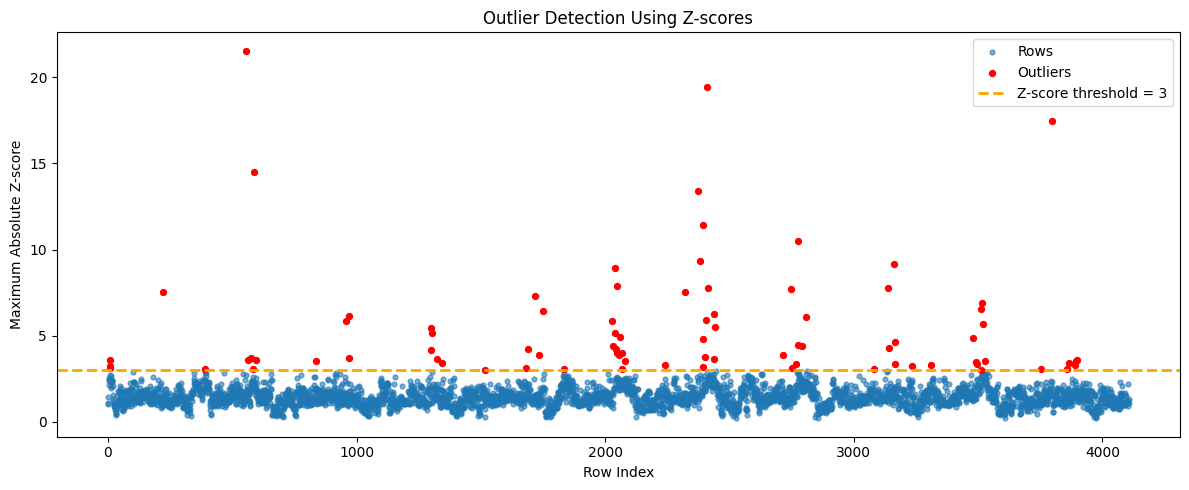

In [14]:
max_z = np.abs(z_scores).max(axis=1)

plt.figure(figsize=(12, 5))
plt.scatter(df_clean.index, max_z, s=12, alpha=0.6, label="Rows")
plt.scatter(df_clean.index[outliers_mask], max_z[outliers_mask], color="red", s=18, label="Outliers")
plt.axhline(3, color="orange", linestyle="--", linewidth=2, label="Z-score threshold = 3")
plt.title("Outlier Detection Using Z-scores")
plt.xlabel("Row Index")
plt.ylabel("Maximum Absolute Z-score")
plt.legend()
plt.tight_layout()
plt.show()

### 🧹 Outlier Handling Strategy

Outliers were identified using Z-scores, with a threshold of (|Z| > 3). Rather than removing all outliers indiscriminately, a domain-aware approach was applied to distinguish between data errors, noise, and meaningful extreme weather events.

#### 1. Dropping Invalid Observations

Rows were **dropped** only when they violated known physical or logical constraints:

* ( T2M_MAX < T2M_MIN )
* ( T2M_RANGE \neq T2M_MAX - T2M_MIN )
* Relative humidity ((RH2M)) outside the range ([0, 100])
* Negative wind speed values

These represent data inconsistencies or measurement errors rather than true outliers.
In our case no such data was found. 

---

#### 2. Retaining Multi-variable Outliers

Rows where **two or more variables simultaneously exceeded the Z-score threshold** were **retained**. These accounted for approximately **1% of the dataset (6 rows)**.

These observations are likely to represent **real meteorological events**, such as:

* Storms (e.g., high wind speed and high precipitation)
* Temperature anomalies (e.g., unusually hot or cold days)

For example, **3 rows were identified as storm events**, characterized by concurrent high values in `WS2M_MAX` and `PRECTOTCORR`. Such patterns are physically meaningful and should be preserved.
we have also seen all outliers might be rearly extreme values so the data outliers were all retained.

---

#### 3. Capping Single-variable Outliers

Rows where **only one variable exceeded the Z-score threshold** were treated as potential noise or measurement spikes. Instead of removing these rows, the extreme values were **capped** using percentile-based clipping (1st and 99th percentiles).

This approach:

* Reduces the impact of extreme values on analysis and modeling
* Preserves the overall structure and continuity of the dataset

In the data there were no single variable outliers

---

#### **Final Strategy Summary**

| Category                               | Action     | Rationale          |
| -------------------------------------- | ---------- | ------------------ |
| Physically inconsistent values         | **Drop**   | Data errors        |
| Multi-variable outliers (≥2 variables) | **Retain** | Likely real events |
| Single-variable outliers               | **Cap**    | Likely noise       |

---

This approach ensures that important extreme weather patterns are preserved while minimizing the influence of erroneous or noisy data points.


In [15]:
outlier_counts = pd.Series((z_scores > 3).sum(axis=0), index=cols_to_check)
total_rows_per_col = df_clean[cols_to_check].notna().sum(axis=0)

outlier_counts = pd.DataFrame({
    "Outlier_Count": outlier_counts,
    "Outlier_Percentage (%)": (outlier_counts / total_rows_per_col) * 100
})

print(outlier_counts)

             Outlier_Count  Outlier_Percentage (%)
T2M                      3                0.073028
T2M_MAX                  6                0.146056
T2M_MIN                  1                0.024343
PRECTOTCORR             71                1.728335
RH2M                     3                0.073028
WS2M                     4                0.097371
WS2M_MAX                 3                0.073028


### Detecting Invalid Observations

In [16]:
# Data quality checks
humidity_col = "RH2M" if "RH2M" in df_clean.columns else "Humidity"
wind_col = "WS2M" if "WS2M" in df_clean.columns else "Wind speed"

checks = pd.DataFrame(index=df_clean.index)

# 1) T2M_MAX < T2M_MIN
checks["T2M_MAX_lt_T2M_MIN"] = df_clean["T2M_MAX"] < df_clean["T2M_MIN"]

# 2) T2M_RANGE != T2M_MAX - T2M_MIN
expected_range = df_clean["T2M_MAX"] - df_clean["T2M_MIN"]
checks["T2M_RANGE_mismatch"] = ~np.isclose(df_clean["T2M_RANGE"], expected_range, equal_nan=True)

# 3) Humidity < 0 or > 100
checks["Humidity_out_of_bounds"] = (df_clean[humidity_col] < 0) | (df_clean[humidity_col] > 100)

# 4) Wind speed < 0
checks["Wind_speed_negative"] = df_clean[wind_col] < 0

# Combine and report
checks["any_issue"] = checks.any(axis=1)

print("Issue counts by rule:")
print(checks.drop(columns="any_issue").sum())

print(f"\nTotal rows with at least one issue: {checks['any_issue'].sum()}")

# Show problematic rows with relevant columns
problem_rows = df_clean.loc[
    checks["any_issue"],
    [c for c in ["Date", "T2M_MIN", "T2M_MAX", "T2M_RANGE", humidity_col, wind_col] if c in df_clean.columns]
].copy()

problem_rows["T2M_MAX_lt_T2M_MIN"] = checks.loc[checks["any_issue"], "T2M_MAX_lt_T2M_MIN"].values
problem_rows["T2M_RANGE_mismatch"] = checks.loc[checks["any_issue"], "T2M_RANGE_mismatch"].values
problem_rows["Humidity_out_of_bounds"] = checks.loc[checks["any_issue"], "Humidity_out_of_bounds"].values
problem_rows["Wind_speed_negative"] = checks.loc[checks["any_issue"], "Wind_speed_negative"].values

if not problem_rows.empty:
    print(problem_rows.head(10))

Issue counts by rule:
T2M_MAX_lt_T2M_MIN        0
T2M_RANGE_mismatch        0
Humidity_out_of_bounds    0
Wind_speed_negative       0
dtype: int64

Total rows with at least one issue: 0


In [17]:
df_temp = df_clean.copy()

In [18]:
df_temp["is_outlier"] = outliers_mask
df_temp["outlier_count"] = df_temp[cols_to_check].apply(lambda row: (row > 3).sum(), axis=1)

### Detect Multi-variable Outliers

In [19]:
T2M_idx = cols_to_check.index("T2M")
T2M_MAX_idx = cols_to_check.index("T2M_MAX")
T2M_MIN_idx = cols_to_check.index("T2M_MIN")
WS2M_MAX_idx = cols_to_check.index("WS2M_MAX")
PRECTOTCORR_idx = cols_to_check.index("PRECTOTCORR")
RH2M_idx = cols_to_check.index("RH2M")

df_temp["heatwave_flag"] = (
    df_temp["is_outlier"] &
    (z_scores[:, T2M_idx] > 2) &
    (z_scores[:, T2M_MAX_idx] > 2) &
    (z_scores[:, T2M_MIN_idx] > 2)
)

df_temp["storm_flag"] = (
    df_temp["is_outlier"] &
    (z_scores[:, WS2M_MAX_idx] > 2) &
    (z_scores[:, PRECTOTCORR_idx] > 2) &
    (df_temp["RH2M"] > 70)
)

In [20]:
heatwaves = df_temp["heatwave_flag"].sum()
storms = df_temp["storm_flag"].sum()
print("Number of heatwave days:", heatwaves)
print("Number of Storm days:", storms)

Number of heatwave days: 5
Number of Storm days: 0


In [21]:
outlier_mask = df_temp["is_outlier"]
outlier_df = df_temp.loc[outlier_mask]

# Run consistency checks only on outlier rows
temp_consistency = (
    (outlier_df["T2M_MIN"] <= outlier_df["T2M"]) &
    (outlier_df["T2M"] <= outlier_df["T2M_MAX"]) &
    (np.abs(outlier_df["T2M_RANGE"] - (outlier_df["T2M_MAX"] - outlier_df["T2M_MIN"])) < 1e-3)
)

wind_consistency = outlier_df["WS2M"] <= outlier_df["WS2M_MAX"]
humidity_consistency = (outlier_df["RH2M"] >= 0) & (outlier_df["RH2M"] <= 100)

p95_rain = outlier_df["PRECTOTCORR"].quantile(0.95)
storm_consistency = ~(
    (outlier_df["PRECTOTCORR"] > p95_rain) &
    (outlier_df["RH2M"] < 30)  # suspicious: heavy rain but very dry air
)

relationship_valid_outliers = (
    temp_consistency &
    wind_consistency &
    humidity_consistency &
    storm_consistency
)

# Map back to full index (non-outliers set to False)
relationship_valid = pd.Series(False, index=df_temp.index)
relationship_valid.loc[outlier_df.index] = relationship_valid_outliers

# Keep multi-variable logic within outliers only
multi_mask = outlier_mask & (df_temp["outlier_count"] >= 2)

valid_multi = multi_mask & relationship_valid
invalid_multi = multi_mask & ~relationship_valid

print("Outlier rows checked:", outlier_mask.sum())
print("Valid multi-variable outliers:", valid_multi.sum())
print("Invalid multi-variable outliers:", invalid_multi.sum())

Outlier rows checked: 84
Valid multi-variable outliers: 83
Invalid multi-variable outliers: 1


### Remove invalid multi-variable outliers

In [25]:
# Remove invalid multi-variable outliers using boolean masking
keep_mask_clean = ~invalid_multi.reindex(df_clean.index, fill_value=False)
keep_mask_temp = ~invalid_multi.reindex(df_temp.index, fill_value=False)

removed_clean = (~keep_mask_clean).sum()
removed_temp = (~keep_mask_temp).sum()

print(f"Invalid multi-variable outliers to remove from df_clean: {removed_clean}")
print(f"Invalid multi-variable outliers to remove from df_temp: {removed_temp}")

df_clean = df_clean[keep_mask_clean].copy()
df_temp = df_temp[keep_mask_temp].copy()

print("Masking applied to df_clean and df_temp.")

Invalid multi-variable outliers to remove from df_clean: 1
Invalid multi-variable outliers to remove from df_temp: 1
Masking applied to df_clean and df_temp.


In [27]:
print("Outlier rows checked:", df_temp["is_outlier"].sum())

Outlier rows checked: 83


## Handle remaining missing values

In [29]:
# check missing values
df_clean.isna().sum()

YEAR           0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

## Export the cleaned DataFrame

In [30]:
df_clean.head()

,YEAR,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1


In [ ]:
os.makedirs("data", exist_ok=True)

country = "sudan"
output_path = f"data/{country}_clean.csv"

print("Saving to:", os.path.abspath(output_path))

df_clean.to_csv(output_path, index=False)

print("Exists after save:", os.path.exists(output_path))
df_temp = pd.read_csv('data/sudan_clean.csv')
df_temp.head()


Saving to: c:\Users\teMelkishi\Desktop\projects\tenx\projects\climate-challenge-week0\notebooks\data\ethiopia_clean.csv
Exists after save: True


,YEAR,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1


# **Time Series Analysis**

In [33]:
df_clean["Month"].value_counts()

Month
1     372
3     372
7     341
8     341
10    341
12    341
5     340
2     339
4     330
6     330
9     330
11    330
Name: count, dtype: int64

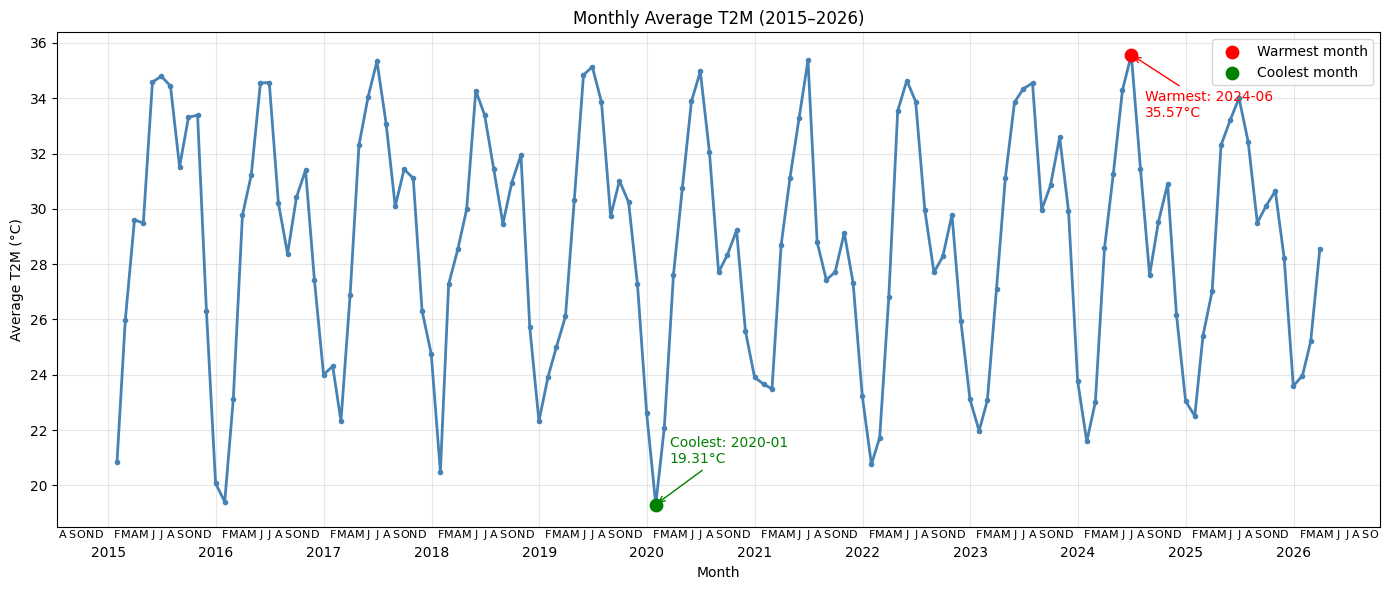

In [34]:
monthly_avg_t2m = df_clean.set_index("Date")["T2M"].resample("ME").mean()

warmest_month = monthly_avg_t2m.idxmax()
coolest_month = monthly_avg_t2m.idxmin()

plt.figure(figsize=(14, 6))
plt.plot(
    monthly_avg_t2m.index,
    monthly_avg_t2m.values,
    color="steelblue",
    linewidth=2,
    marker="o",
    markersize=3
)

plt.scatter([warmest_month], [monthly_avg_t2m[warmest_month]], color="red", s=80, zorder=5, label="Warmest month")
plt.scatter([coolest_month], [monthly_avg_t2m[coolest_month]], color="green", s=80, zorder=5, label="Coolest month")

plt.annotate(
    f"Warmest: {warmest_month.strftime('%Y-%m')}\n{monthly_avg_t2m[warmest_month]:.2f}°C",
    xy=(warmest_month, monthly_avg_t2m[warmest_month]),
    xytext=(10, -45),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="red"),
    color="red"
)

plt.annotate(
    f"Coolest: {coolest_month.strftime('%Y-%m')}\n{monthly_avg_t2m[coolest_month]:.2f}°C",
    xy=(coolest_month, monthly_avg_t2m[coolest_month]),
    xytext=(10, 30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="green"),
    color="green"
)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_minor_formatter(FuncFormatter(lambda x, pos: mdates.num2date(x).strftime("%b")[0]))

ax.tick_params(axis="x", which="major", length=0, pad=14, labelsize=10)
ax.tick_params(axis="x", which="minor", length=0, pad=2, labelsize=8)

plt.title("Monthly Average T2M (2015–2026)")
plt.xlabel("Month")
plt.ylabel("Average T2M (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

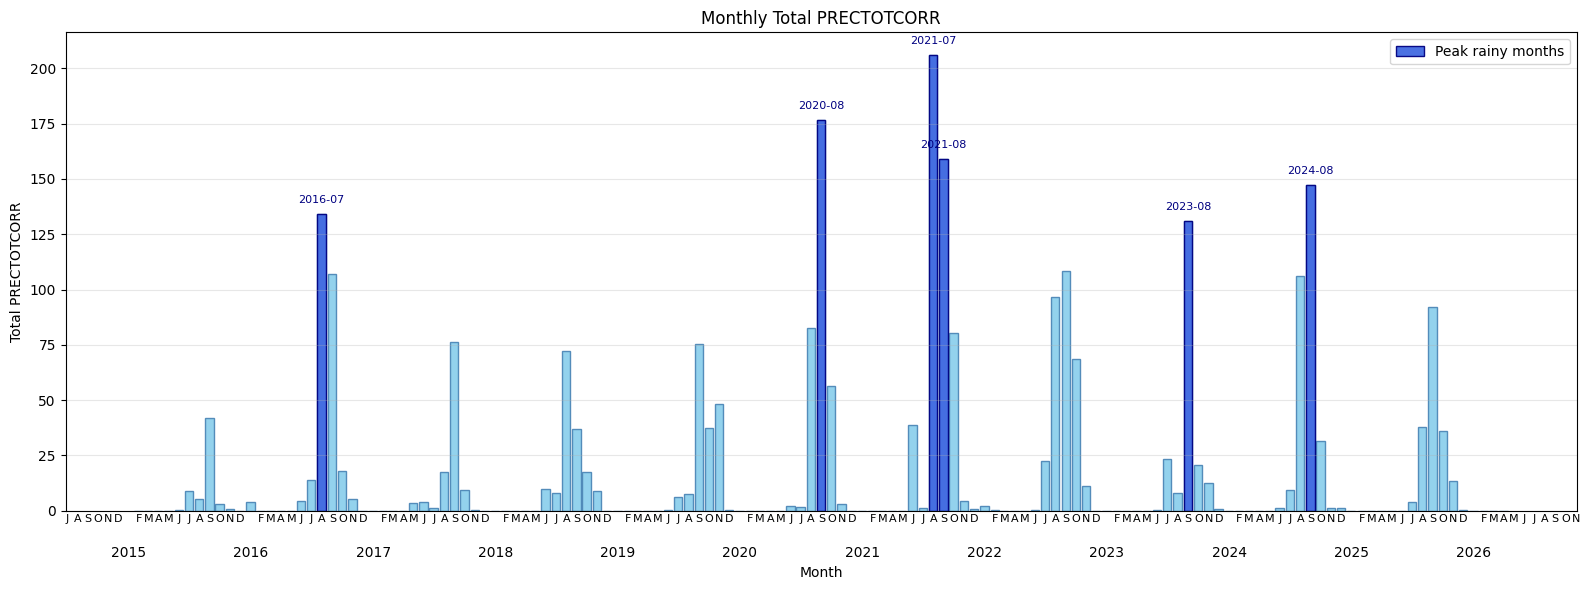

Peak rainy-season months (highest monthly totals):
Date
2016-07-31    134.31
2020-08-31    176.73
2021-07-31    205.97
2021-08-31    159.06
2023-08-31    131.06
2024-08-31    147.31
Name: PRECTOTCORR, dtype: float64


In [35]:
# Monthly total precipitation (PRECTOTCORR)
monthly_total_prectotcorr = df_clean.set_index("Date")["PRECTOTCORR"].resample("ME").sum()

# Pick peak rainy-season months (top 6 wettest months in the full time series)
peak_months = monthly_total_prectotcorr.nlargest(6).sort_index()

plt.figure(figsize=(16, 6))
plt.bar(
    monthly_total_prectotcorr.index,
    monthly_total_prectotcorr.values,
    width=25,
    color="skyblue",
    edgecolor="steelblue",
    alpha=0.9
)

# Highlight and annotate peak months
plt.bar(
    peak_months.index,
    peak_months.values,
    width=25,
    color="royalblue",
    edgecolor="navy",
    alpha=0.95,
    label="Peak rainy months"
)


for dt, val in peak_months.items():
    plt.annotate(
        dt.strftime("%Y-%m"),
        xy=(dt, val),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        color="navy"
    )

ax = plt.gca()

# Year label every year
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("\n%Y"))

# Month labels as first letter (J, F, M, ...)
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_minor_formatter(
    FuncFormatter(lambda x, pos: mdates.num2date(x).strftime("%b")[0])
)

ax.tick_params(axis="x", which="major", length=0, pad=14, labelsize=10)
ax.tick_params(axis="x", which="minor", length=0, pad=2, labelsize=8)

plt.title("Monthly Total PRECTOTCORR")
plt.xlabel("Month")
plt.ylabel("Total PRECTOTCORR")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Peak rainy-season months (highest monthly totals):")
print(peak_months)

## Climate Trends and Anomalies: Sudan (2015–2026)

### Precipitation (Monthly Total PRECTOTCORR)
*   **Clear seasonal pattern**: The region exhibits a strong annual rainfall cycle, with the primary wet season consistently peaking in **July - September**. Dark blue bars highlight these peak periods.
*   **Key anomalies**:
    *   **Highest recorded rainfall**: **August 2021**, reaching a peak of approximately **205.97 mm**.
    *   Other significant spikes occurred in **September 2020 (176.73 mm)**, **August 2024 (147.31 mm)**, **September 2021 (159.06)** and **August 2016 (134.31 mm)**.
*   **Trend**: There is high inter-annual variability. The period between 2020 and 2021 shows the most intense rainfall activity, while the years 2015, 2017–2019, and 2022 appear relatively drier.

### Temperature (Monthly Average T2M)
*   **Clear seasonal cycle**: Temperatures follow a bimodal trend. Peaks generally occur in the spring season, while the sharpest temperature drops often occur at the start of the year (January).
*   **Key anomalies**:
    *   **Warmest month**: **June 2024**, reaching a significant high of **35.57°C**.
    *   **Coolest month**: **January 2020**, dropping to **19.31°C**.
*   **Trend**: Temperature variability has become more pronounced from 2020 onwards, with sharper peaks and more frequent fluctuations compared to the 2015–2018 period.

### Relationship Between Precipitation and Temperature
*   **Cooling effect of rain**: The wettest months (**August-September**) typically see a decline in temperature compared to the pre-monsoon heat of **May–June**. This is clearly visible in 2024, where the record high of 35.57°C in June is followed by a sharp drop as the August rains arrive.
*   **Notable co-occurrences**:
    *   **The 2020 "Cold" Peak**: Interestingly, the coolest month on record (**January 2020**) occurred just a few months before one of the most intense rainy seasons (August 2020), marking 2020 as a year of high thermal and hydrological contrast.
    *   **The 2021 Deluge**: The highest rainfall peak (July 2021) coincides with a mid-year temperature dip, confirming that heavy cloud cover and moisture suppress average surface temperatures.
*   **Implication**: The data suggests that while temperatures are highly seasonal, extreme rainfall events act as a "thermal regulator," preventing extreme heat during the peak of the Kiremt season. The hottest periods occur immediately before the main rains begin.

***

**Summary of Observations:**
The charts indicate that Sudan is experiencing increasingly intense individual weather events, particularly the record-breaking heat in **mid-2024** and the record-breaking rainfall in **mid-2021**. The inverse relationship between moisture and heat remains a dominant feature of the local climate.

# **Correlation & Relationship Analysis**

### Heatmap of correlations across all numeric columns

In [43]:
# which columns are numberic
df_clean.select_dtypes(include=[np.number]).columns.tolist()

['YEAR',
 'T2M',
 'T2M_MAX',
 'T2M_MIN',
 'T2M_RANGE',
 'PRECTOTCORR',
 'RH2M',
 'WS2M',
 'WS2M_MAX',
 'PS',
 'QV2M',
 'Month']

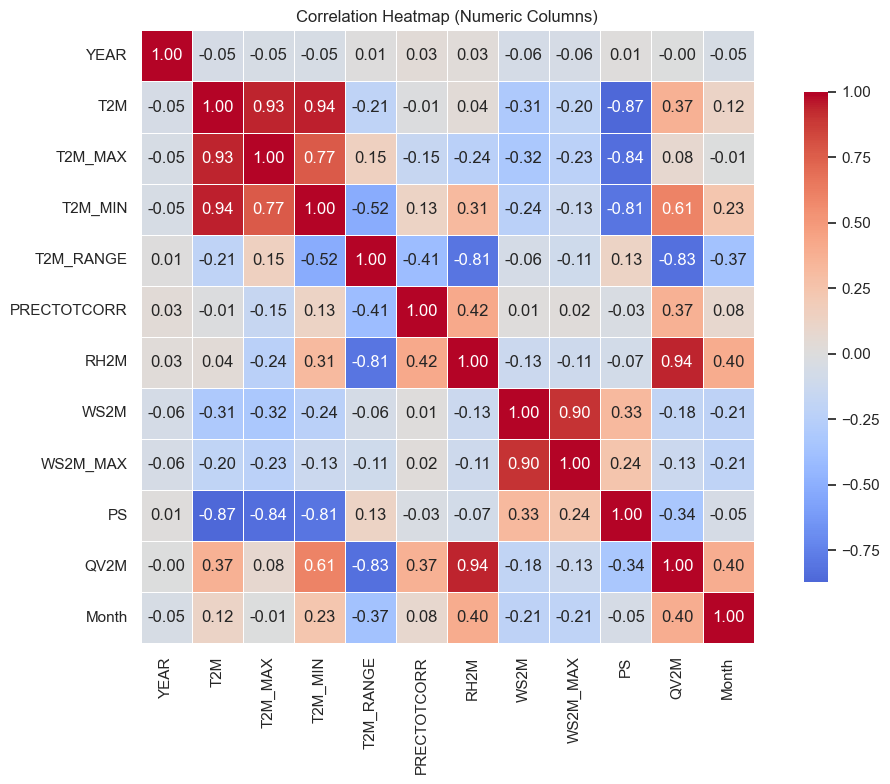

In [44]:
# Correlation heatmap across all numeric columns in df_clean
numeric_df = df_clean.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap (Numeric Columns)")
plt.tight_layout()
plt.show()

## Scatter plots

### T2M vs. RH2M and T2M_RANGE vs. WS2M

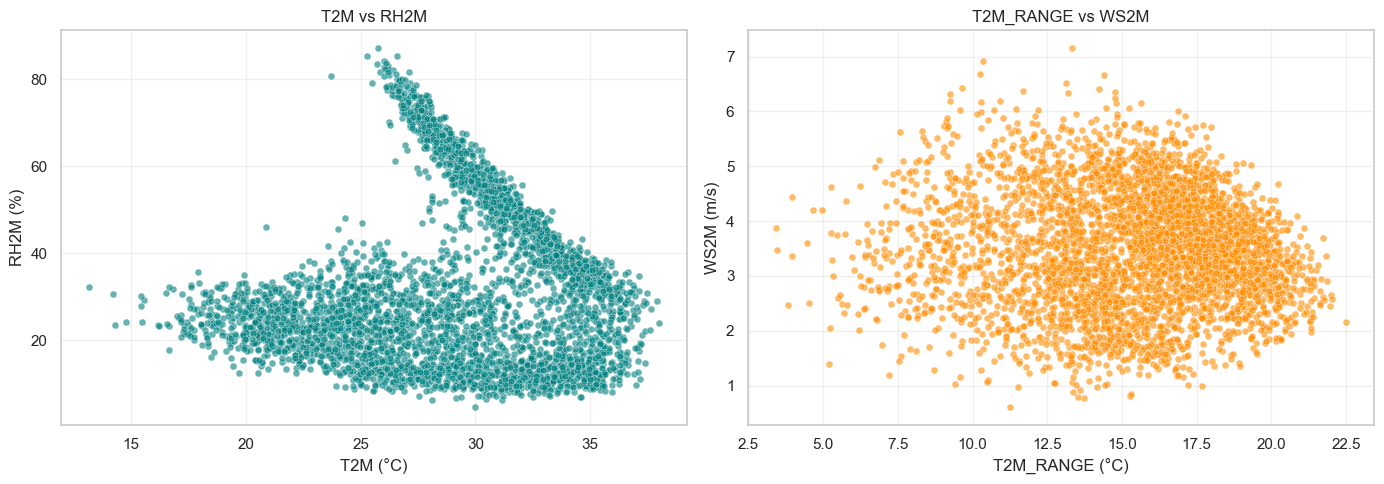

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df_clean, x="T2M", y="RH2M",
    alpha=0.6, s=25, ax=axes[0], color="teal"
)
axes[0].set_title("T2M vs RH2M")
axes[0].set_xlabel("T2M (°C)")
axes[0].set_ylabel("RH2M (%)")
axes[0].grid(alpha=0.3)

sns.scatterplot(
    data=df_clean, x="T2M_RANGE", y="WS2M",
    alpha=0.6, s=25, ax=axes[1], color="darkorange"
)
axes[1].set_title("T2M_RANGE vs WS2M")
axes[1].set_xlabel("T2M_RANGE (°C)")
axes[1].set_ylabel("WS2M (m/s)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Three Strongest Correlations

#### 1. Strong Bifurcated Relationship between T2M and RH2M (Left Plot)
*   **Identification:** The "T2M vs RH2M" plot reveals two distinct regimes. There is a **sharp negative correlation** (the "tail" at the top) where Relative Humidity (RH) drops from ~85% to ~40% as temperature increases from 25°C to 35°C. Simultaneously, there is a large, dense cluster at the bottom representing a "dry regime" with RH mostly staying below 40%.
*   **Interpretation:** The upper branch likely represents the "wet season" or humid days where the temperature-humidity coupling is tight (as air warms, its capacity to hold moisture increases, causing RH to drop). The lower cluster represents "dry season" or arid conditions where moisture is limited regardless of the temperature.

#### 2. Very Weak / Near-Zero Correlation (Right Plot)

* slightly positive from low ranges (~5–10°C) to mid ranges (~14–17°C) then flat or slightly negative afterward
* So overall, it looks more like a weak nonlinear pattern rather than a clear linear correlation.
* Weak or negligible correlation between T2M_RANGE and WS2M, with a slight positive tendency in the middle range.

***

### Key Takeaway
The most striking feature is the **"Hook" shape** in the Temperature vs. Humidity plot. It shows that once temperatures cross approximately **25°C**, the atmosphere follows one of two paths: it either remains very dry (bottom cluster) or follows a strict physical decay in humidity (top branch), likely dictated by whether or not there is an active moisture source (like the monsoon) present.

# **Distribution Analysis**

In [46]:
df_clean.head()

,YEAR,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1


### **Histogram of PRECTOTCORR**

#### Check if the histogram of PRECTOTCORR

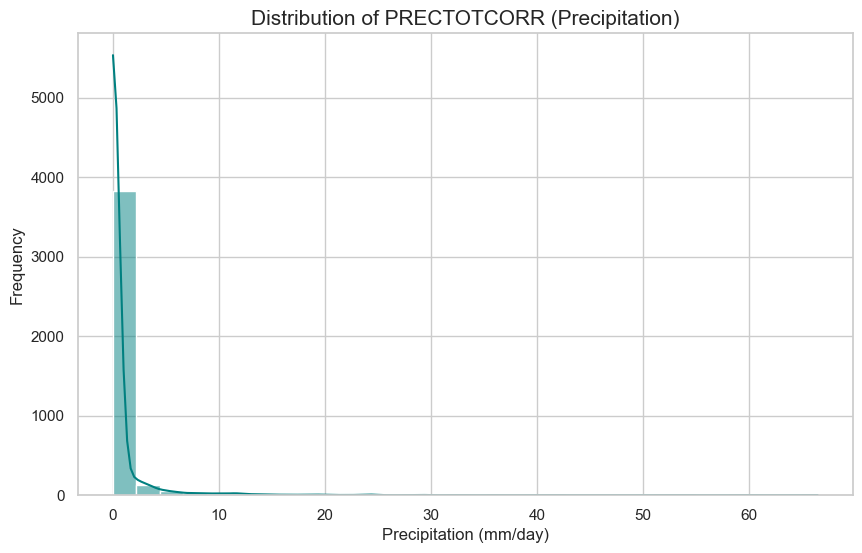

In [47]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(df['PRECTOTCORR'], kde=True, color='teal', bins=30)

plt.title('Distribution of PRECTOTCORR (Precipitation)', fontsize=15)
plt.xlabel('Precipitation (mm/day)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

Because the distribution of PRECTOTCORR is heavily skewed we apply log scale to the X-axis to better visualize the distribution.

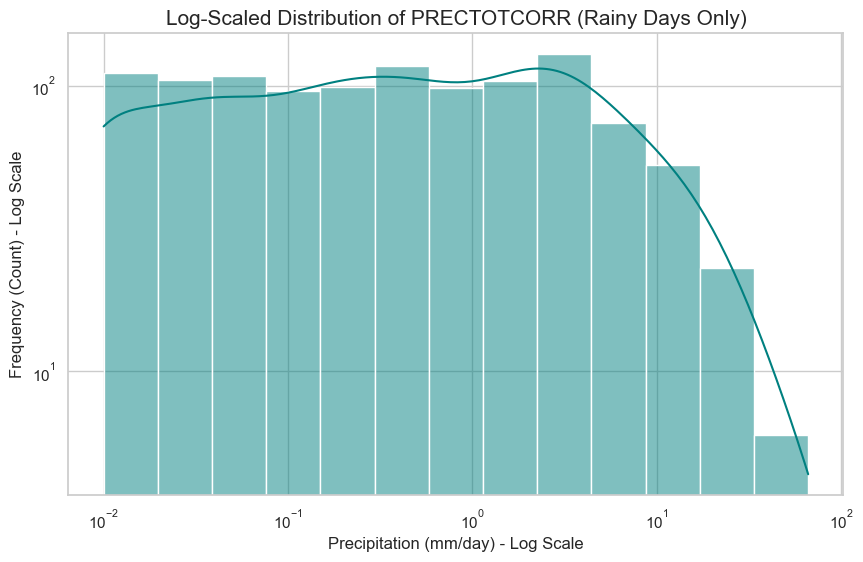

In [48]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6)) 

# Filtering for values > 0 is necessary for log scales because log(0) is undefined
rainy_days = df[df['PRECTOTCORR'] > 0]['PRECTOTCORR']

# log_scale=True automatically calculates log-spaced bins for the X-axis
sns.histplot(rainy_days, kde=True, color='teal', log_scale=True)

# Also applying log scale to the Y-axis (Frequency) to see rare extreme events better
plt.yscale('log')

plt.title('Log-Scaled Distribution of PRECTOTCORR (Rainy Days Only)', fontsize=15)
plt.xlabel('Precipitation (mm/day) - Log Scale', fontsize=12)
plt.ylabel('Frequency (Count) - Log Scale', fontsize=12)

plt.show()

### **Bubble chart**

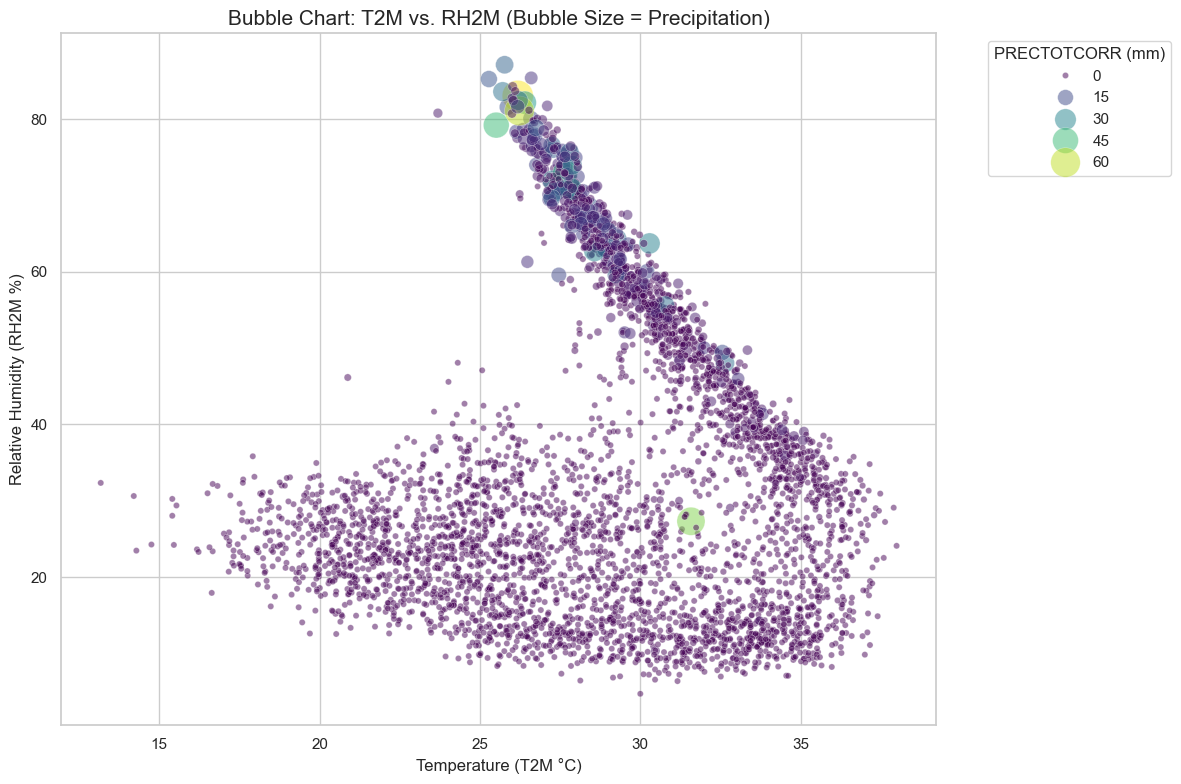

In [49]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 8))

# Create the bubble chart
# s=df['PRECTOTCORR'] * 20: Scale factor to make bubbles visible
# alpha=0.5: Transparency to see overlapping bubbles
# hue='PRECTOTCORR': Colors bubbles by precipitation intensity for better clarity
bubble_plot = sns.scatterplot(
    data=df, 
    x='T2M', 
    y='RH2M', 
    size='PRECTOTCORR', 
    hue='PRECTOTCORR',
    sizes=(20, 500),      
    alpha=0.5,           
    palette='viridis'     
)

# Customizing the chart
plt.title('Bubble Chart: T2M vs. RH2M (Bubble Size = Precipitation)', fontsize=15)
plt.xlabel('Temperature (T2M °C)', fontsize=12)
plt.ylabel('Relative Humidity (RH2M %)', fontsize=12)

# Move the legend outside to avoid overlap
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='PRECTOTCORR (mm)')

plt.tight_layout()
plt.show()

### Interpretation of Bubble Chart: T2M vs. RH2M (Precipitation)

This bubble chart adds a third dimension, **Precipitation (PRECTOTCORR)**, to the relationship between temperature and relative humidity for the study area. Here is an analysis of the key patterns observed:

#### 1. The "Rainy Sweet Spot"
*   **Observation:** The largest bubbles (representing high precipitation, 45mm to 60mm+) are almost exclusively clustered at the top of the "hook" pattern.
*   **Interpretation:** Significant rainfall occurs only when **Relative Humidity is very high (between 75% and 85%)**. Once the humidity drops below 60%, even at favorable temperatures, precipitation amounts fall off drastically, confirming that atmospheric saturation is the primary driver for rain events in this region.

#### 2. Temperature Window for Peak Precipitation
*   **Observation:** The heaviest rainfall events (the largest, light-colored bubbles) are concentrated within a specific warm temperature window, roughly **25°C to 33°C**.
*   **Interpretation:** Unlike cooler climates, the most intense precipitation in this region occurs during warm conditions. This suggests that the rainy season (likely the monsoon) is characterized by high-energy, warm air masses that can hold and release significant moisture.

#### 3. The "Dry Regime" (Low Humidity = Zero Rain)
*   **Observation:** The vast majority of the chart area, particularly the large cluster between 15% and 40% RH, is populated by tiny purple dots (0mm rain).
*   **Interpretation:** For a wide range of temperatures (**15°C to 38°C**), if the relative humidity is low, precipitation is non-existent. This vast "dry regime" illustrates the arid nature of the region during the majority of the year when moisture sources are unavailable.

#### 4. High-Temperature Suppression
*   **Observation:** As temperatures climb toward the extreme right of the graph (**above 32°C**), the bubbles disappear and the RH drops below 40%.
*   **Interpretation:** At extreme heat, the air's capacity to hold moisture increases so significantly that it becomes very difficult to reach the saturation point required for rain. Consequently, the hottest days in this region are consistently the driest.

#### 5. Precipitation Anomaly
*   **Observation:** There is a notable outlier—a large green bubble (approx. 45mm) located at roughly **31.5°C and only 27% RH**.
*   **Interpretation:** This is an anomaly that may represent a rare, high-intensity convective event (like a sudden thunderstorm) that occurred during a generally dry, hot period, or a specific localized weather event.

### Summary
The chart demonstrates a **strong three-way dependency**: heavy precipitation requires a specific "Goldilocks" zone of moderate-to-high temperatures (**25–28°C**) combined with near-saturated humidity (**>75%**). Outside of this specific window, the environment remains almost entirely dry, regardless of how high the temperature rises.